In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree, naive_bayes, linear_model, metrics


# Funções para Análise de Métricas

In [2]:
# Para as funções, precisam de 3 variáveis no dataframe: Target, Predict, Predict Proba

def Metricas(df, modelo):

    # Métricas
    cm = pd.crosstab(df['Target'], df['Predict'])
    vn, fn, fp, vp =cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    acc = metrics.accuracy_score(df['Target'], df['Predict'])
    prec = metrics.precision_score(df['Target'], df['Predict'])
    recall = metrics.recall_score(df['Target'], df['Predict'])
    espec = vn / (vn + fp)

    # Printando os valores das métricas
    print(modelo)
    print('=='*20)

    print(f'Accuracy: {acc*100:.2f}%')
    print(f'Precision: {prec*100:.2f}%')
    print(f'Recall: {recall*100:.2f}%')
    print(f'espec: {espec*100:.2f}%')
    print(f'1 - espec: {(1 - espec)*100:.2f}%')

def MatrizConfusao(df, modelo):

    matriz_confusao = pd.crosstab(df['Target'], df['Predict'])

    plt.Figure(dpi=400)
    plt.Figure(figsize=(18, 8))

    sns.heatmap(matriz_confusao, annot=True, fmt=".2f", cmap="YlOrRd")

    plt.title("Matriz de Confusão " + modelo)
    plt.xlabel("Target")
    plt.ylabel("Predict")

    plt.show()

def CurvaROC(df, modelo):

    # Métricas da Curva ROC
    roc = metrics.roc_curve(df['Target'], df['Predict Proba'])
    auc = metrics.roc_auc_score(df['Target'], df['Predict Proba'])

    plt.figure(dpi=400)
    plt.Figure(figsize=(18,8))

    plt.plot(roc[0], roc[1])
    plt.grid(True)

    plt.title("Curva ROC " + modelo)
    plt.xlabel("1 - Especificidade")
    plt.ylabel("Recall")

    plt.legend([f'{modelo}: {auc:.2f}'])
    
    plt.show()

def AnaliseModelo(df, modelo):

    Metricas(df, modelo)   

    print("\n")

    MatrizConfusao(df, modelo)

    print("\n")

    CurvaROC(df, modelo)

    
    





# Definindo os dados dos modelos

In [3]:
df = pd.read_csv('../data/abt_comunidade.csv', sep=';')
df.head()

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,feliz
0,0,0,1,0,0,0,0,1,0,0,...,0,1,1,0,1,1,1,0,34,1
1,0,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,0,0,1,26,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,1,1,39,1
3,0,0,0,0,0,0,1,0,0,0,...,1,0,1,1,1,1,1,0,27,1
4,0,0,0,0,1,0,0,0,0,1,...,1,0,1,1,1,1,0,0,29,1


In [4]:
features = df.columns[:-1].tolist()

X = df[features]
y = df['feliz']

# Definindo Modelos

## Árvore

In [5]:
# Árvore

arvore = tree.DecisionTreeClassifier(random_state=42, min_samples_leaf=6)

arvore.fit(X, y)


,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [6]:
df_arv = df[['feliz']]
df_arv = df_arv.rename({'feliz' : 'Target'}, axis=1)

arv_predict = arvore.predict(X)
arv_predict_proba = arvore.predict_proba(X)[:,1]

df_arv['Predict'] = arv_predict
df_arv['Predict Proba'] = arv_predict_proba

df_arv

,Target,Predict,Predict Proba
0,1,1,0.777778
1,1,1,0.846154
2,1,1,0.857143
3,1,1,0.857143
4,1,1,1.000000
...,...,...,...
177,1,1,0.857143
178,1,1,1.000000
179,0,0,0.285714
180,0,0,0.500000


## Naive Bayes

In [7]:
naive = naive_bayes.GaussianNB()

naive.fit(X, y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[ 35.,147.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.19,0.81]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,5.437e-08
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](55,)","['Como conheceu o Téo Me Why?_Amigos', 'Como conheceu o Téo Me Why?_Instagram', 'Como conheceu o Téo Me Why?_LinkedIn',...,'Curte jogos de fórmula 1?', 'Curte jogos de MMA?','Idade']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,55
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 55)","[[ 0.23, 0.17, 0.2 ,..., 0.37, 0.23,31.46], [ 0.13, 0.12, 0.26,..., 0.41, 0.24,31.2 ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 55)","[[ 0.18, 0.14, 0.16,..., 0.23, 0.18,34.36], [ 0.11, 0.1 , 0.19,..., 0.24, 0.18,59.12]]"


In [8]:
df_naive = df[['feliz']]
df_naive = df_naive.rename({'feliz' : 'Target'}, axis=1)

naive_predict = naive.predict(X)
naive_predict_proba = naive.predict_proba(X)[:,1]

df_naive['Predict'] = naive_predict
df_naive['Predict Proba'] = naive_predict_proba

df_naive

,Target,Predict,Predict Proba
0,1,0,8.579697e-18
1,1,0,2.420248e-19
2,1,0,3.280598e-10
3,1,0,8.082140e-12
4,1,1,1.000000e+00
...,...,...,...
177,1,0,7.470531e-13
178,1,1,1.000000e+00
179,0,0,3.394327e-20
180,0,0,8.266188e-18


## Regressão Logística

In [9]:
logic = linear_model.LogisticRegression(max_iter=200)

logic.fit(X, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [10]:
df_logic = df[['feliz']]
df_logic = df_logic.rename({'feliz' : 'Target'}, axis=1)

logic_predict = logic.predict(X)
logic_predict_proba = logic.predict_proba(X)[:,1]

df_logic['Predict'] = logic_predict
df_logic['Predict Proba'] = logic_predict_proba

df_logic

,Target,Predict,Predict Proba
0,1,1,0.888482
1,1,1,0.691274
2,1,1,0.981565
3,1,1,0.915386
4,1,1,0.905269
...,...,...,...
177,1,1,0.955329
178,1,1,0.942343
179,0,1,0.535612
180,0,1,0.704656


# Analisando as Métricas

## Árvore

Árvore
Accuracy: 84.62%
Precision: 89.40%
Recall: 91.84%
espec: 54.29%
1 - espec: 45.71%




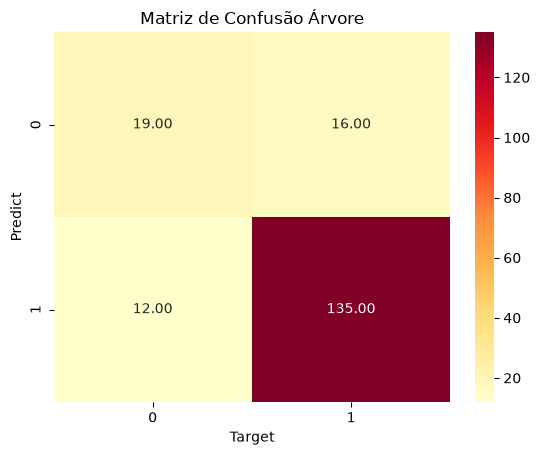

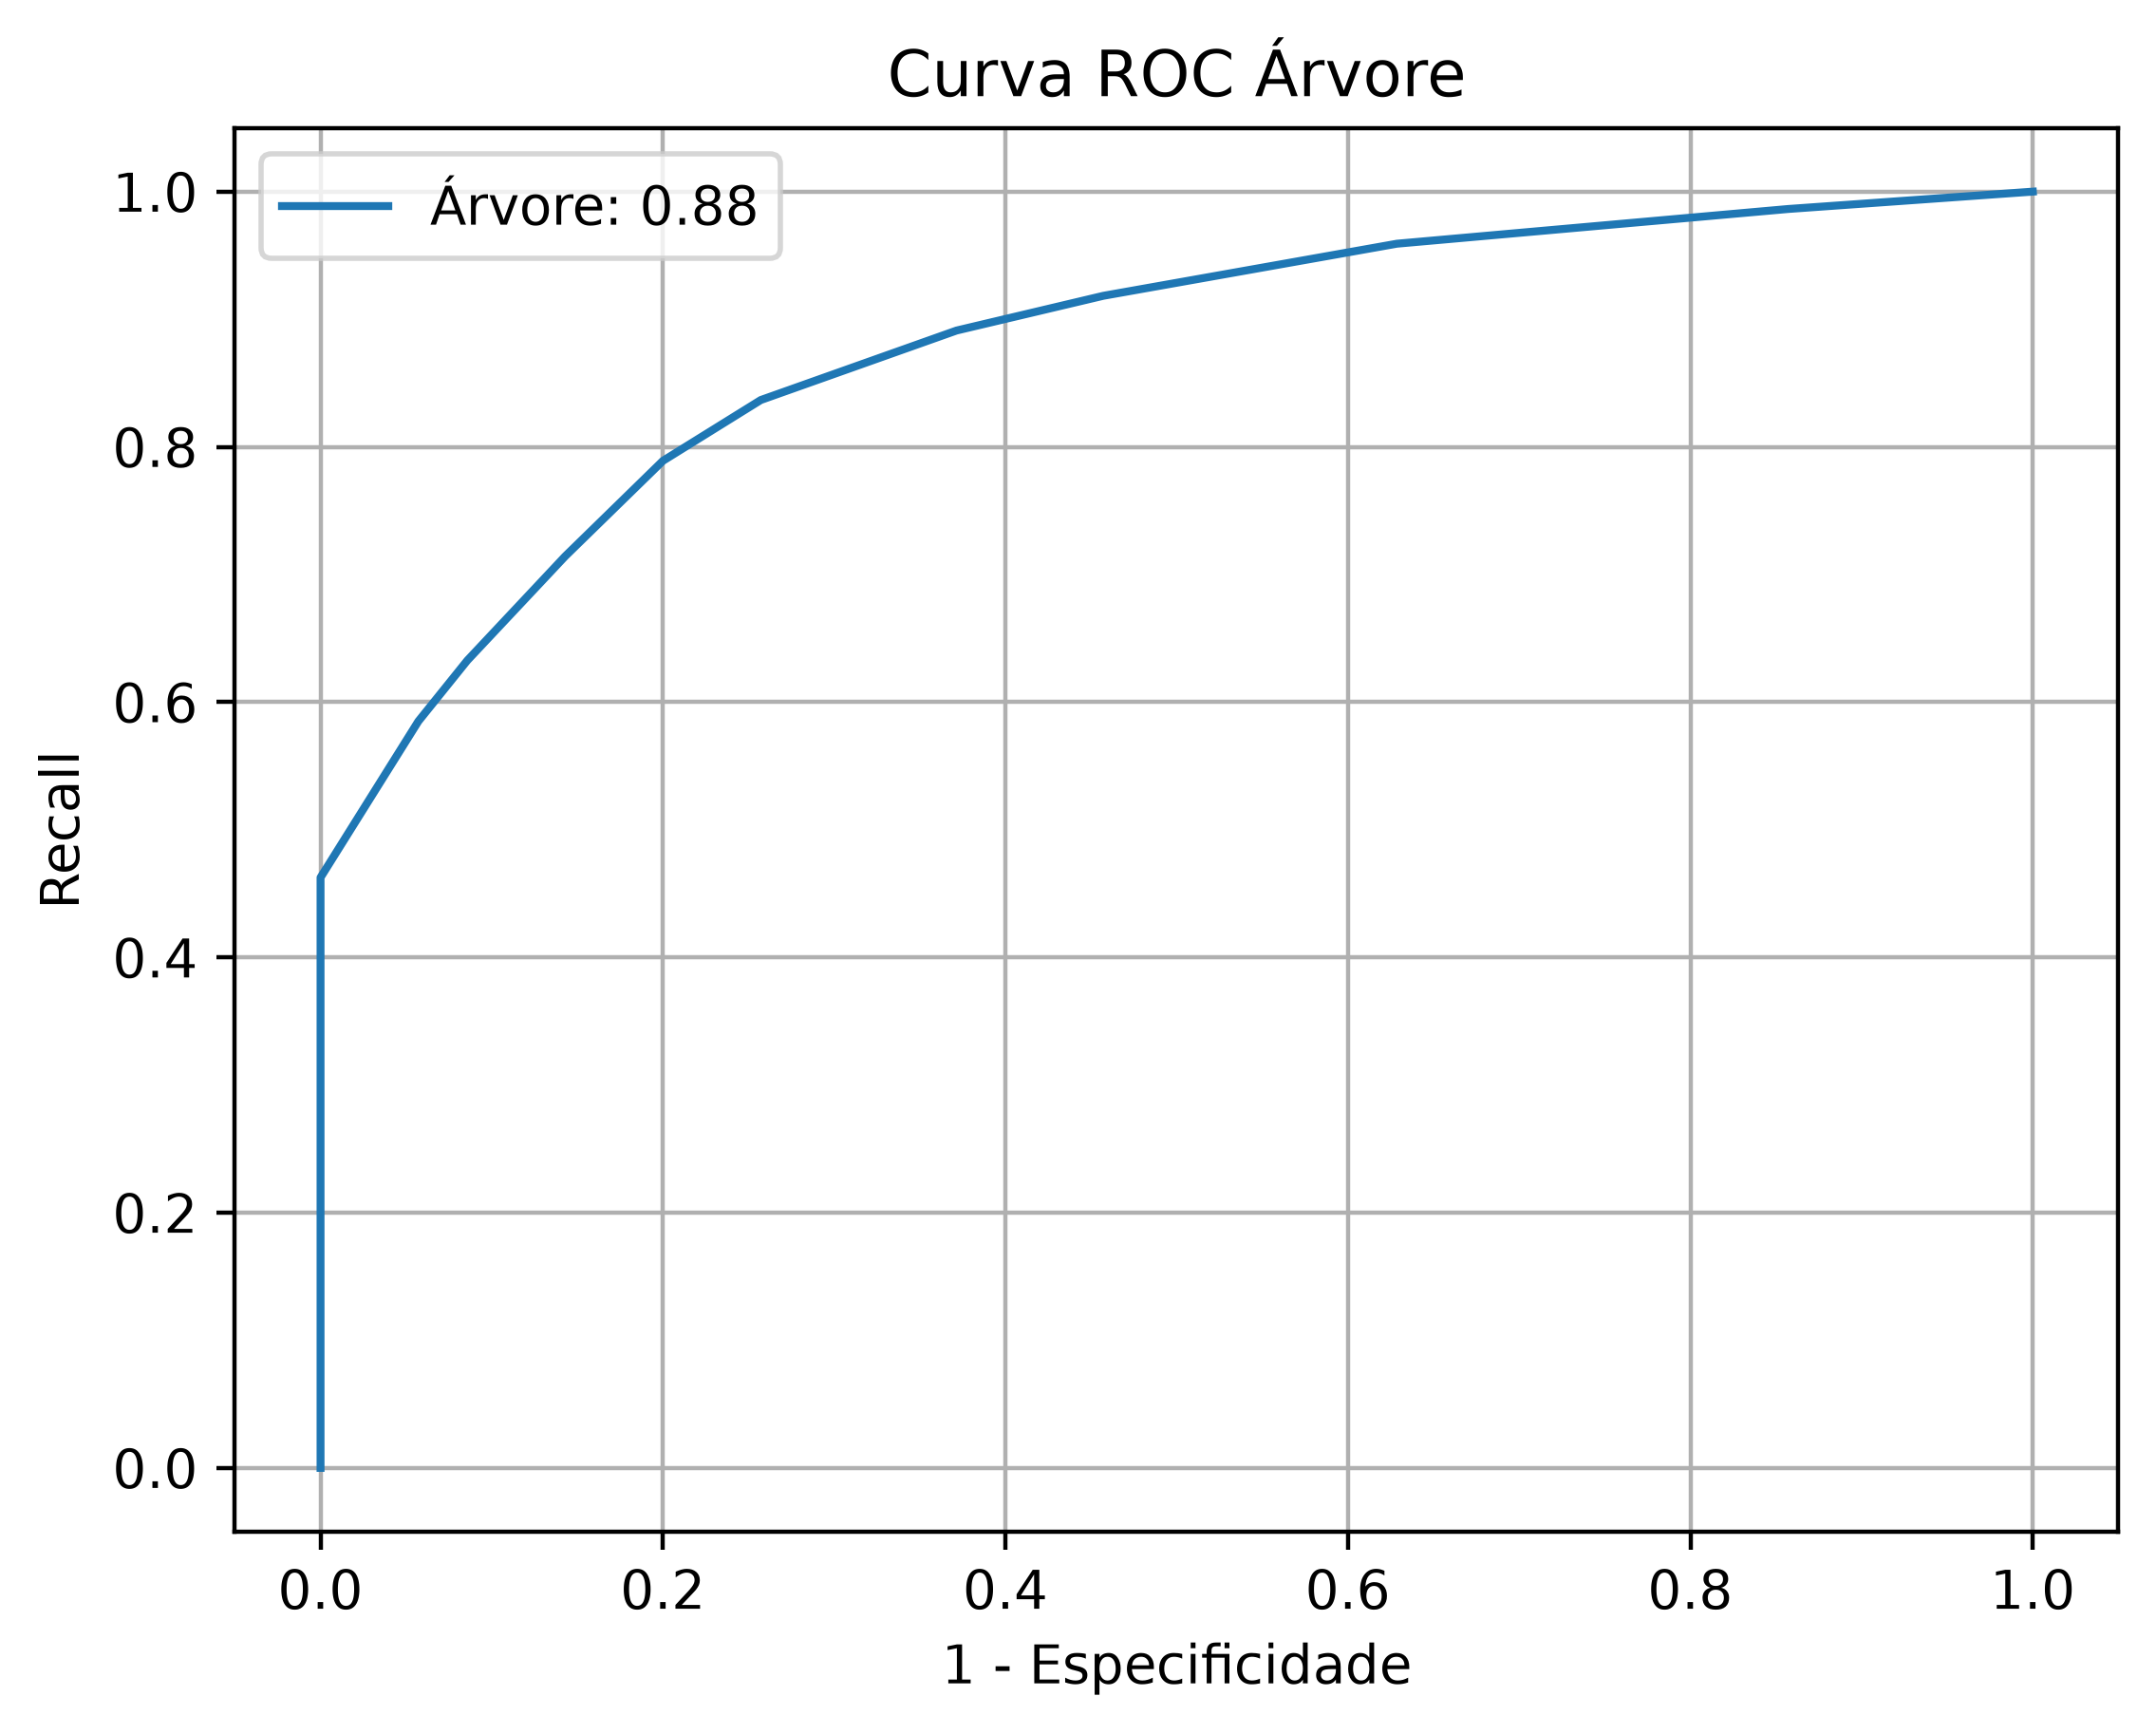

In [11]:
AnaliseModelo(df_arv, 'Árvore')

## Naive Bayes

Naive Bayes
Accuracy: 37.91%
Precision: 100.00%
Recall: 23.13%
espec: 100.00%
1 - espec: 0.00%




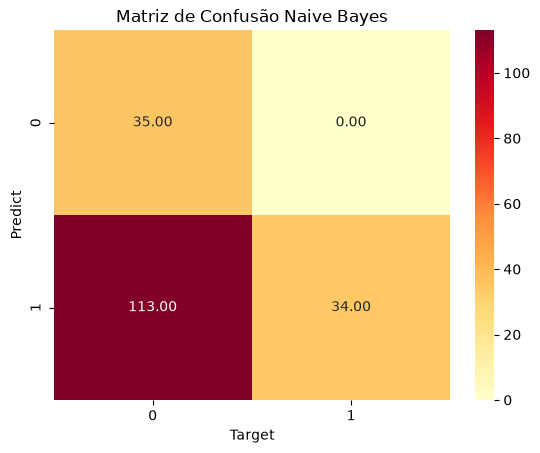

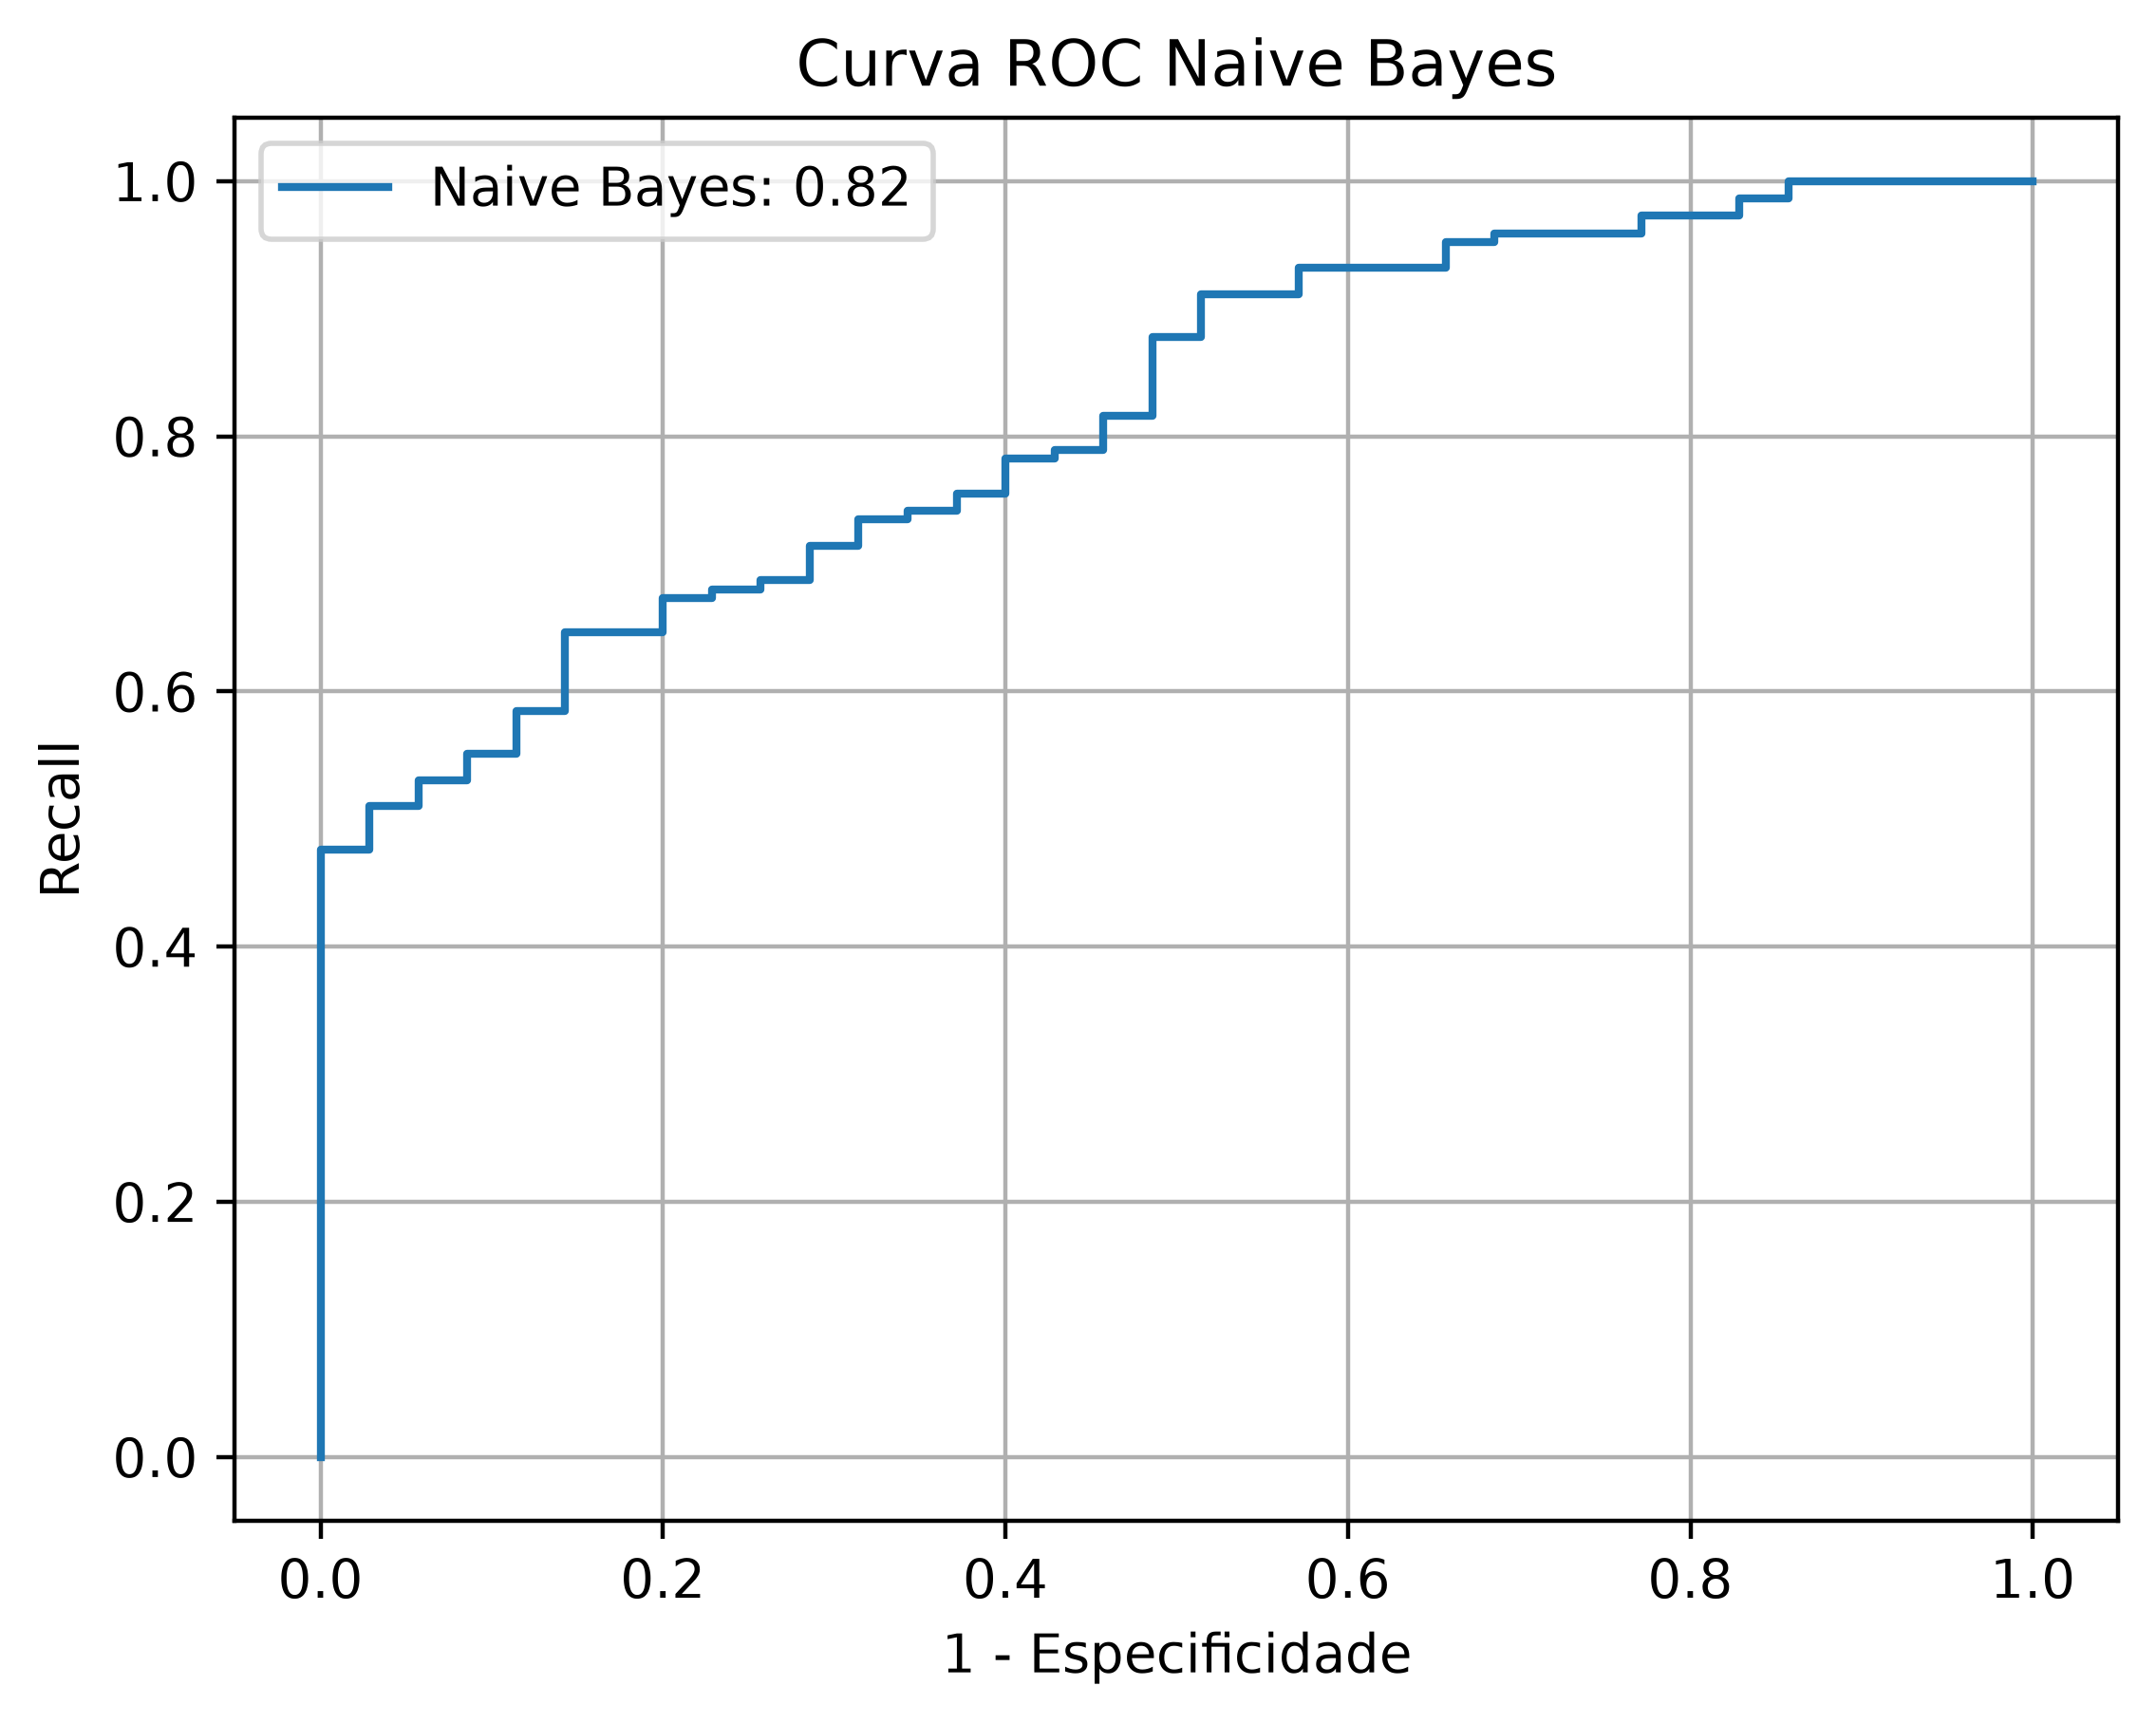

In [12]:
AnaliseModelo(df_naive, 'Naive Bayes')

## Regressão Logística

Regressão Logística
Accuracy: 81.87%
Precision: 82.02%
Recall: 99.32%
espec: 8.57%
1 - espec: 91.43%




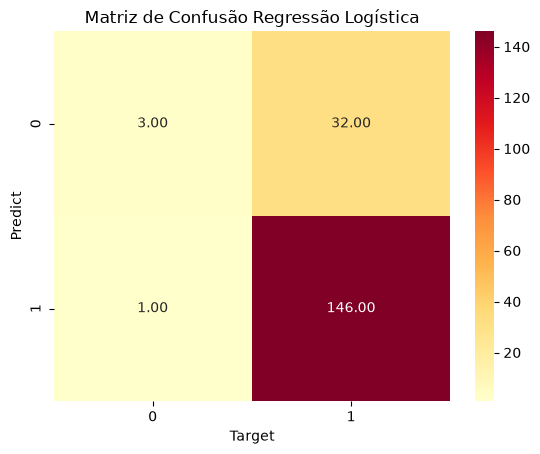

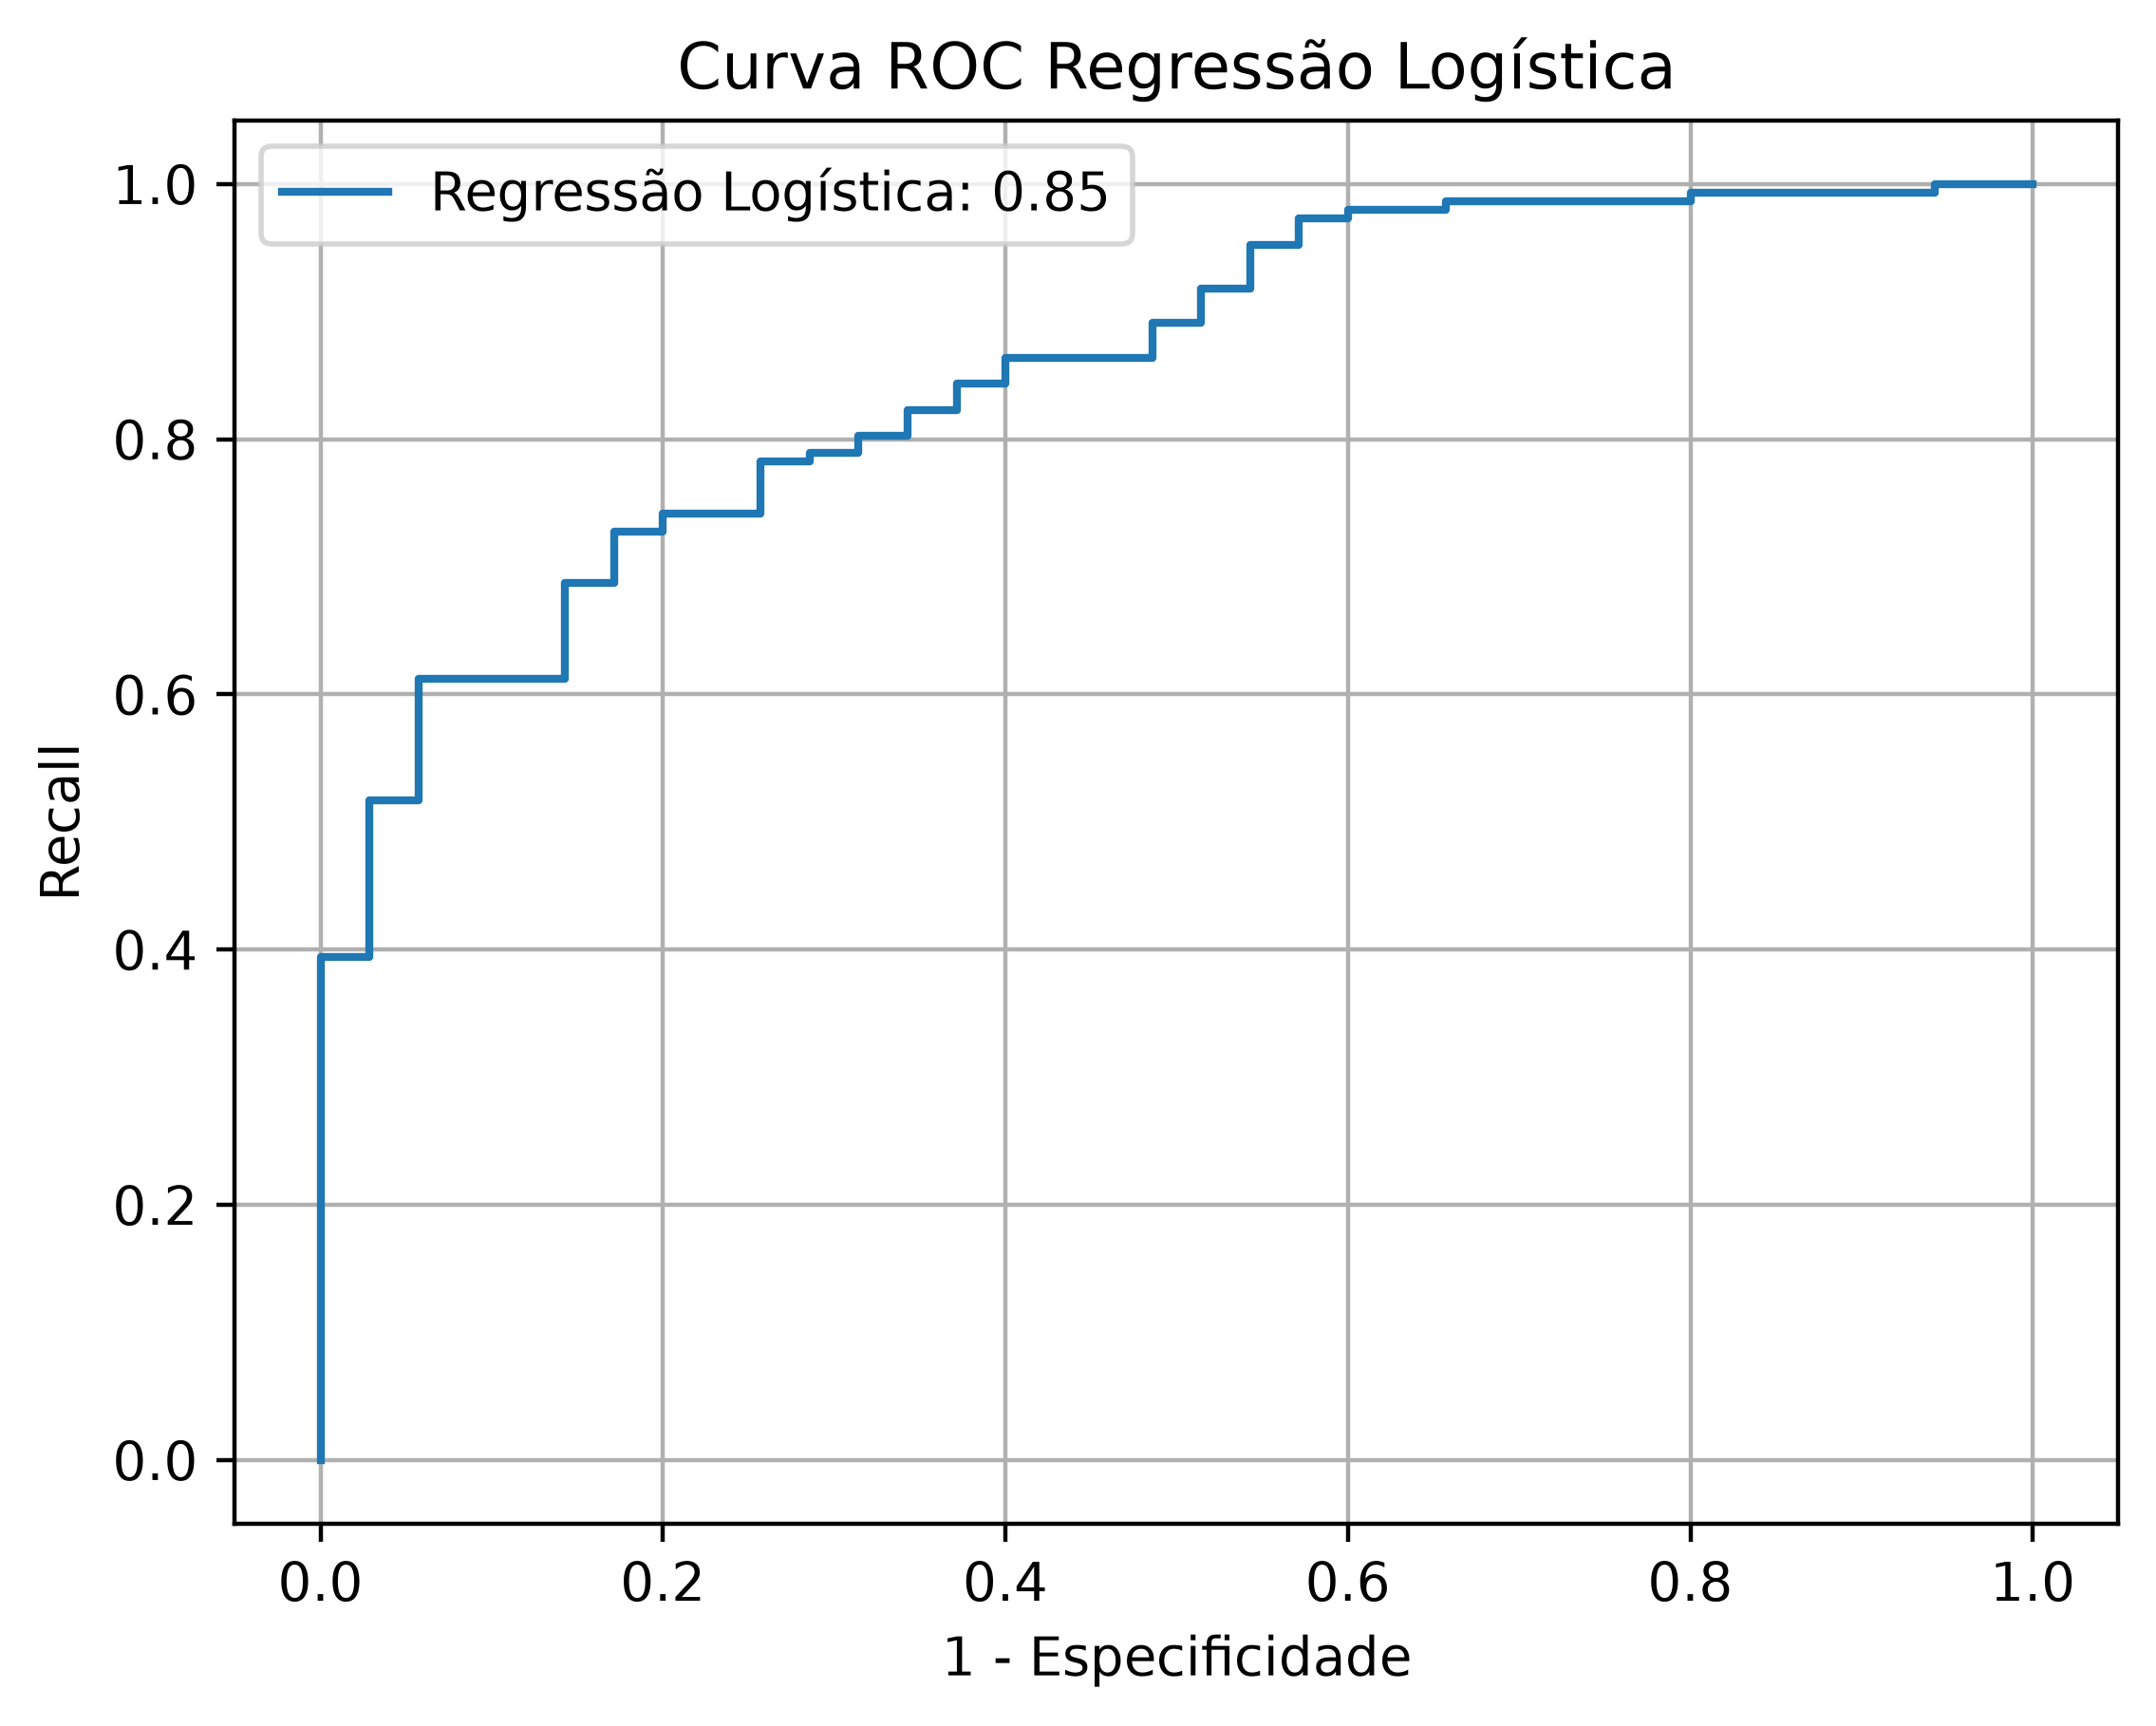

In [13]:
AnaliseModelo(df_logic, 'Regressão Logística')